In [1]:
import os
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
import albumentations as A

c:\Users\HP\anaconda3\envs\dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
BASE = r"C:\Users\HP\Desktop\GAVE2_preliminary\training"

with open("dataset_split.pkl", "rb") as f:
    split = pickle.load(f)

train_files = split["train"]
val_files = split["val"]
test_files = split["test"]

print(len(train_files), len(val_files), len(test_files))

35 7 8


In [4]:
train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=0.5
        )
    ],
    additional_targets={
        "fov": "mask"
    }
)

In [5]:
def convert_av_to_mask(av):
    mask = np.zeros(av.shape[:2], dtype=np.uint8)

    red = np.all(av == [255, 0, 0], axis=-1)
    green = np.all(av == [0, 255, 0], axis=-1)
    blue = np.all(av == [0, 0, 255], axis=-1)

    mask[red] = 1
    mask[green] = 2
    mask[blue] = 3

    return mask

In [6]:
def preprocess_retina(image, fov):
    image = image * fov[:, :, None]

    green = image[:, :, 1]

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(green)

    enhanced = np.stack([enhanced, enhanced, enhanced], axis=-1)

    return enhanced

In [7]:
class AVDataset(Dataset):
    def __init__(self, file_list, base_path, transform=None, resize=(1152, 768)):
        self.file_list = file_list
        self.base_path = base_path
        self.transform = transform
        self.resize = resize

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]

        image_path = os.path.join(self.base_path, "images", filename)
        av_path = os.path.join(self.base_path, "av", filename)
        fov_path = os.path.join(self.base_path, "masks", filename)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        av = cv2.imread(av_path)
        av = cv2.cvtColor(av, cv2.COLOR_BGR2RGB)

        fov = cv2.imread(fov_path, 0)
        fov = (fov > 0).astype(np.uint8)

        mask = convert_av_to_mask(av)

        if self.transform:
            augmented = self.transform(
                image=image,
                mask=mask,
                fov=fov
            )

            image = augmented["image"]
            mask = augmented["mask"]
            fov = augmented["fov"]

        image = preprocess_retina(image, fov)

        image = cv2.resize(image, self.resize)
        mask = cv2.resize(mask, self.resize, interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [8]:
train_dataset = AVDataset(train_files, BASE, transform=train_transform)
val_dataset = AVDataset(val_files, BASE)
test_dataset = AVDataset(test_files, BASE)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, num_workers=0)

In [10]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)
print(torch.unique(masks))

torch.Size([2, 3, 768, 1152])
torch.Size([2, 768, 1152])
tensor([0, 1, 2, 3])


In [11]:
def mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    rgb[mask == 1] = [255, 0, 0]
    rgb[mask == 2] = [0, 255, 0]
    rgb[mask == 3] = [0, 0, 255]

    return rgb

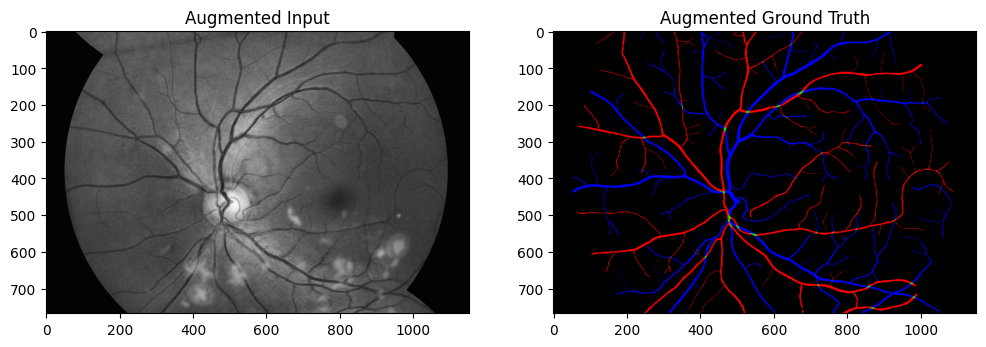

In [12]:
img = images[0].permute(1,2,0).numpy()
mask = masks[0].numpy()

mask_rgb = mask_to_rgb(mask)

fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].imshow(img)
ax[0].set_title("Augmented Input")

ax[1].imshow(mask_rgb)
ax[1].set_title("Augmented Ground Truth")

plt.show()

In [13]:
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4
).to(device)

In [14]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.softmax(preds, dim=1)

        targets_one_hot = torch.nn.functional.one_hot(
            targets, num_classes=preds.shape[1]
        )

        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()

        intersection = (preds * targets_one_hot).sum(dim=(2, 3))
        union = preds.sum(dim=(2, 3)) + targets_one_hot.sum(dim=(2, 3))

        dice = (2 * intersection + self.smooth) / (union + self.smooth)

        loss = 1 - dice.mean()

        return loss

In [15]:
class CombinedLoss(nn.Module):
    def __init__(self, class_weights):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dice = DiceLoss()

    def forward(self, preds, targets):
        ce_loss = self.ce(preds, targets)
        dice_loss = self.dice(preds, targets)

        total_loss = 0.5 * ce_loss + 0.5 * dice_loss

        return total_loss

In [16]:
class_weights = torch.tensor([1.0, 8.0, 30.0, 8.0]).to(device)

criterion = CombinedLoss(class_weights)

In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [18]:
def compute_accuracy(preds, targets):
    preds = torch.argmax(preds, dim=1)
    correct = (preds == targets).float().mean().item()
    return correct

In [19]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    total_acc = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        acc = compute_accuracy(outputs, masks)

        total_loss += loss.item()
        total_acc += acc

    return total_loss / len(loader), total_acc / len(loader)

In [20]:
def validate(model, loader, criterion):
    model.eval()

    total_loss = 0
    total_acc = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            acc = compute_accuracy(outputs, masks)

            total_loss += loss.item()
            total_acc += acc

    return total_loss / len(loader), total_acc / len(loader)

In [21]:
best_val_acc = 0
EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc = validate(
        model, val_loader, criterion
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_aug_av_model.pth")

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print("-"*50)

Epoch 1/20
Train Loss: 1.1876 | Train Acc: 0.2679
Val Loss: 1.0785 | Val Acc: 0.4027
--------------------------------------------------
Epoch 2/20
Train Loss: 1.0547 | Train Acc: 0.4594
Val Loss: 0.9700 | Val Acc: 0.8239
--------------------------------------------------
Epoch 3/20
Train Loss: 0.9567 | Train Acc: 0.6689
Val Loss: 0.8823 | Val Acc: 0.9134
--------------------------------------------------
Epoch 4/20
Train Loss: 0.8727 | Train Acc: 0.7917
Val Loss: 0.8439 | Val Acc: 0.9336
--------------------------------------------------
Epoch 5/20
Train Loss: 0.7961 | Train Acc: 0.8487
Val Loss: 0.8259 | Val Acc: 0.9375
--------------------------------------------------
Epoch 6/20
Train Loss: 0.7344 | Train Acc: 0.8828
Val Loss: 0.7942 | Val Acc: 0.9396
--------------------------------------------------
Epoch 7/20
Train Loss: 0.6864 | Train Acc: 0.9028
Val Loss: 0.7643 | Val Acc: 0.9408
--------------------------------------------------
Epoch 8/20
Train Loss: 0.6461 | Train Acc: 0.916

In [22]:
def mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    rgb[mask == 1] = [255, 0, 0]   # artery
    rgb[mask == 2] = [0, 255, 0]   # overlap
    rgb[mask == 3] = [0, 0, 255]   # vein

    return rgb

In [23]:
model.load_state_dict(torch.load("best_aug_av_model.pth"))
model.eval()

UnetPlusPlus(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, bias=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, bias=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
     

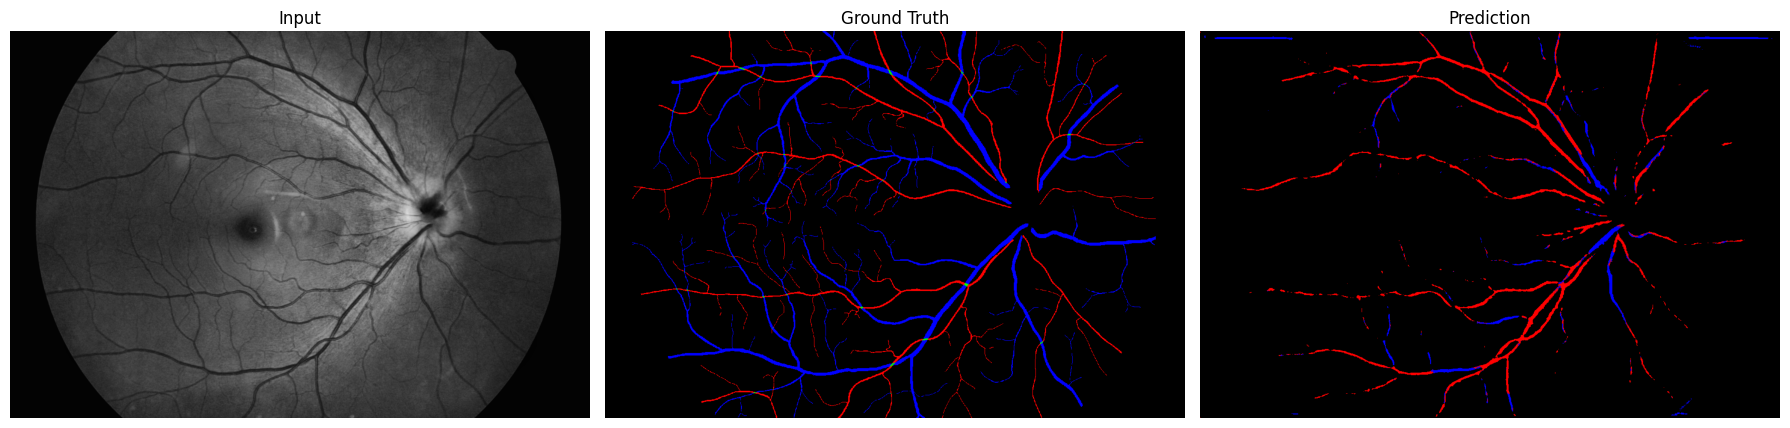

In [24]:
images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

img = images[0].cpu().permute(1, 2, 0).numpy()
gt = masks[0].cpu().numpy()
pred = preds[0].cpu().numpy()

gt_rgb = mask_to_rgb(gt)
pred_rgb = mask_to_rgb(pred)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img)
ax[0].set_title("Input")

ax[1].imshow(gt_rgb)
ax[1].set_title("Ground Truth")

ax[2].imshow(pred_rgb)
ax[2].set_title("Prediction")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

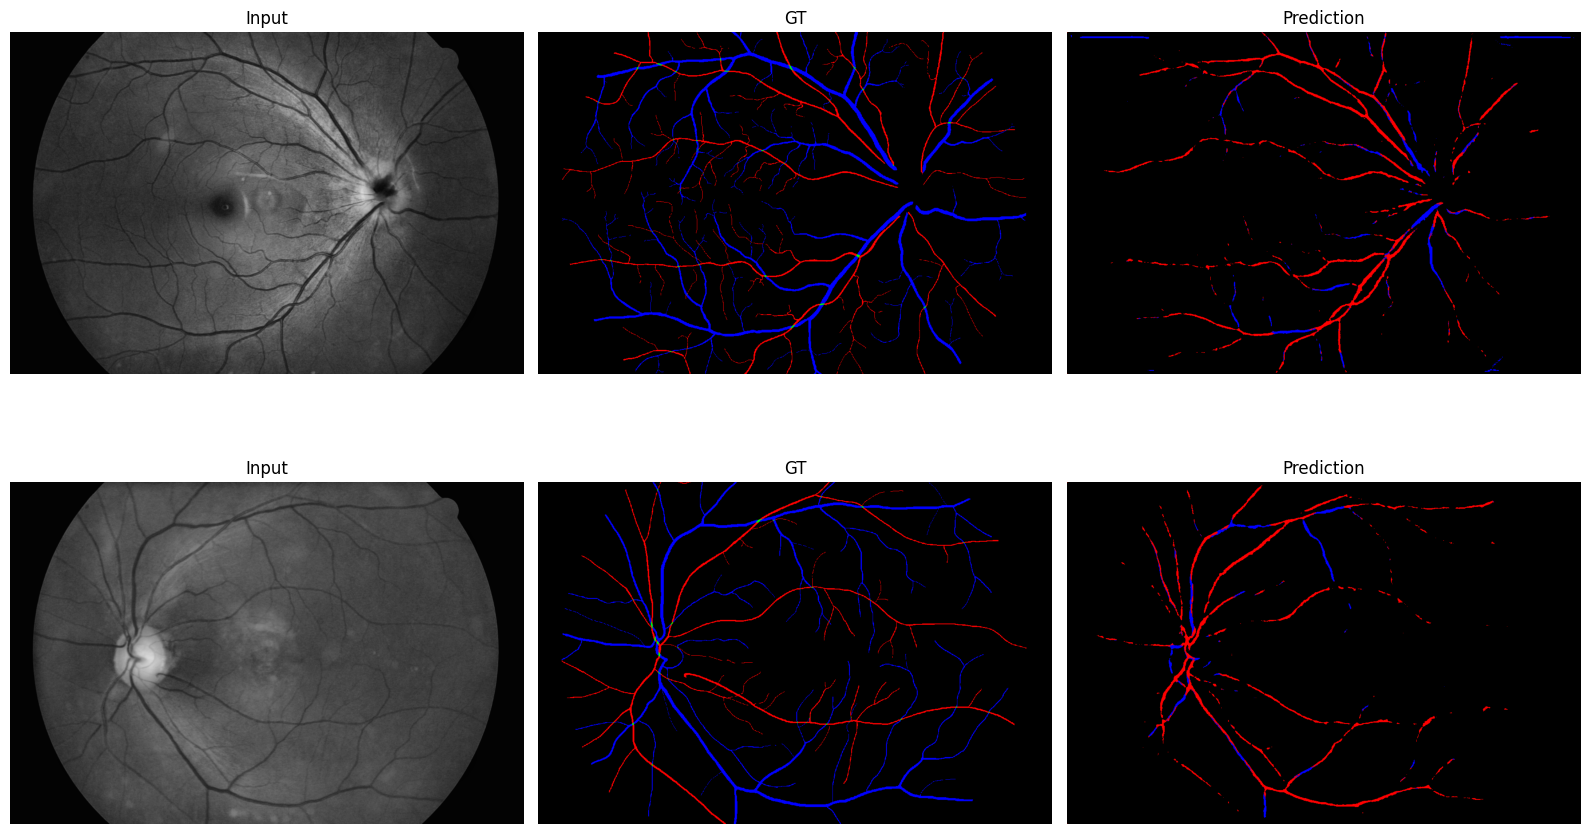

In [25]:
model.eval()

images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

num_samples = images.shape[0]

fig, axes = plt.subplots(num_samples, 3, figsize=(16, 5*num_samples))

if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_samples):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    gt = masks[i].cpu().numpy()
    pred = preds[i].cpu().numpy()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Input")

    axes[i, 1].imshow(mask_to_rgb(gt))
    axes[i, 1].set_title("GT")

    axes[i, 2].imshow(mask_to_rgb(pred))
    axes[i, 2].set_title("Prediction")

    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()